# Python Assignment 7 : MLR

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
data = pd.read_csv('ToyotaCorolla - MLR.csv')
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [82]:
data.dtypes

Price         int64
Age_08_04     int64
KM            int64
Fuel_Type    object
HP            int64
Automatic     int64
cc            int64
Doors         int64
Cylinders     int64
Gears         int64
Weight        int64
dtype: object

In [83]:
data.isna().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [84]:
data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


#### data visualization

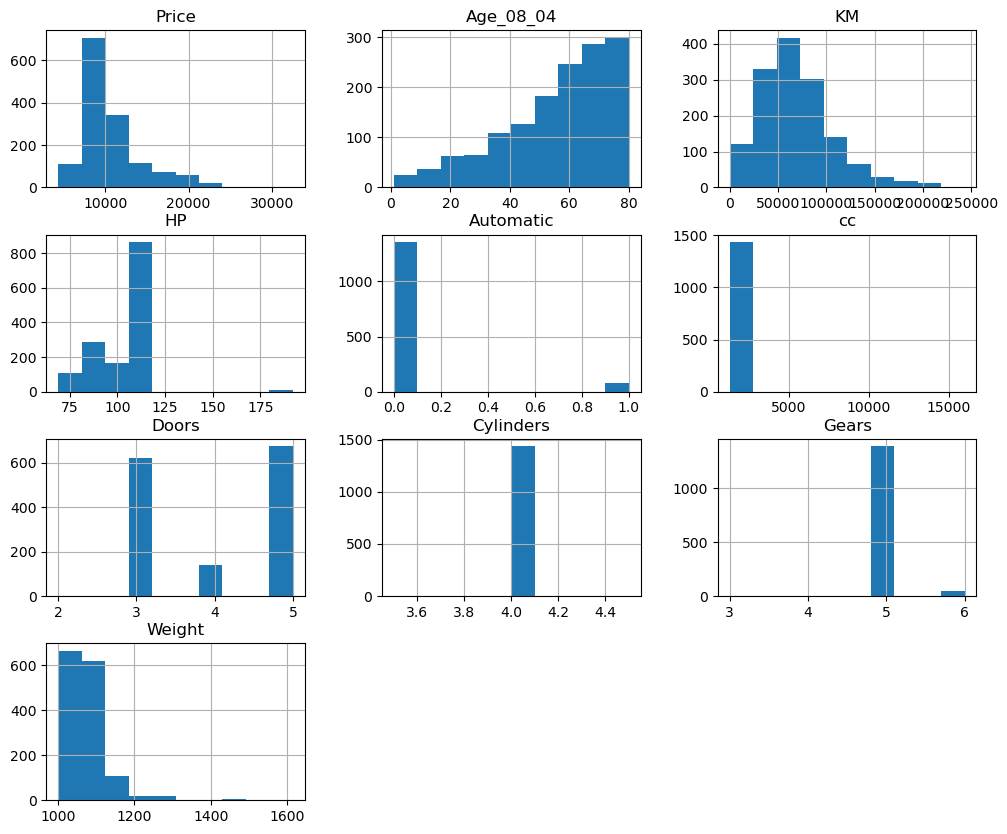

In [85]:
data.hist(figsize=(12,10))
plt.show()


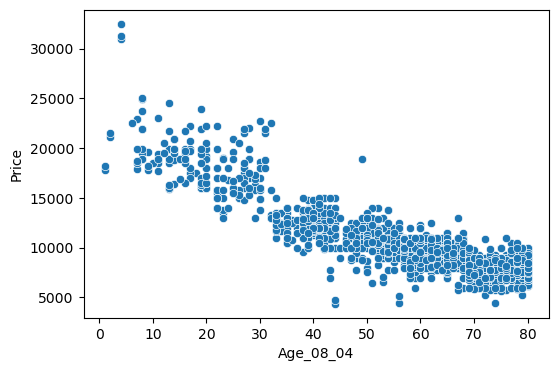

In [86]:
plt.figure(figsize=(6,4))
sns.scatterplot(data, x='Age_08_04', y='Price')
plt.show()

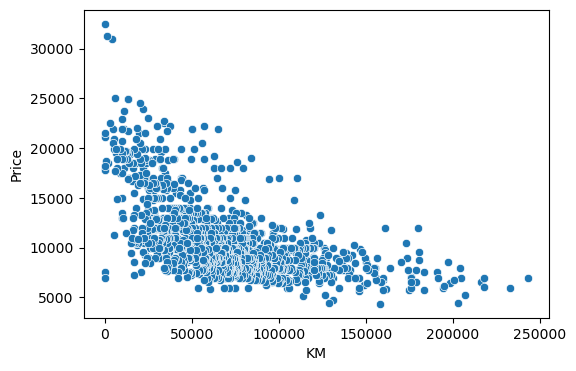

In [87]:
plt.figure(figsize=(6,4))
sns.scatterplot(data, x='KM', y='Price')
plt.show()

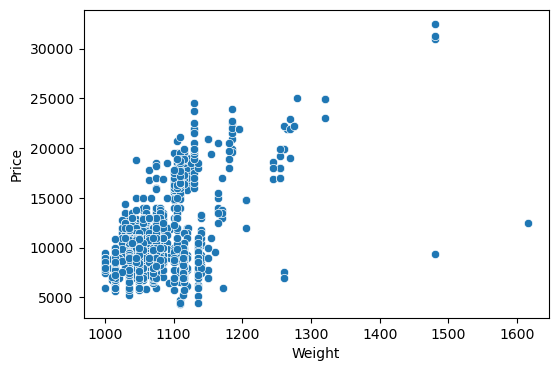

In [88]:
plt.figure(figsize=(6,4))
sns.scatterplot(data, x='Weight', y='Price')
plt.show()

#### data preprocessing 

In [89]:
from sklearn.preprocessing import  LabelEncoder

In [90]:
# encoding 
enc = LabelEncoder()
data['Fuel_Type'] = enc.fit_transform(data['Fuel_Type'])


In [91]:
#data.head()

In [92]:
from sklearn.preprocessing import  StandardScaler

In [93]:
# scaling 
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data)


In [94]:
#scaled_data.head()

In [95]:
# split the data 
X = data.drop('Price', axis=1)
y = data['Price']

In [167]:
data1 = data.loc[:, data.nunique() > 1]


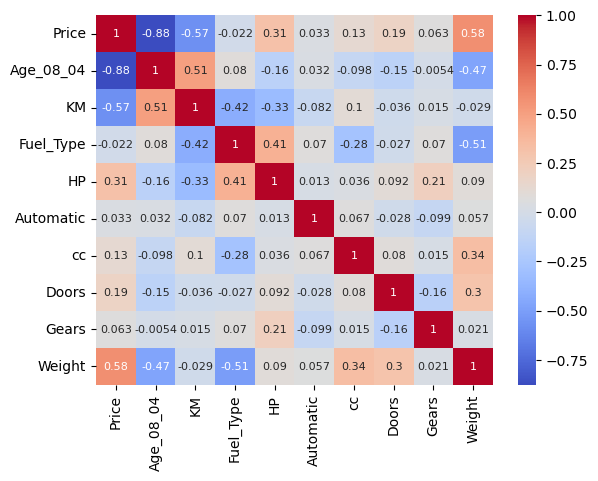

In [168]:
sns.heatmap(data1.corr(), annot=True, cmap='coolwarm', annot_kws={'size':8})
plt.show()

In [140]:
from sklearn.model_selection import train_test_split

### training the data

#### model 1

In [97]:
# split data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1148, 10) (288, 10) (1148,) (288,)


In [98]:
from sklearn.linear_model import LinearRegression

In [99]:
# build model
model1 = LinearRegression()
model1.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [100]:
#make prediction
yhat_train =model1.predict(X_train)

In [101]:
model1.coef_

array([-1.21436240e+02, -1.69355966e-02,  8.62056431e+02,  2.06582831e+01,
        2.45196891e+02, -7.35153881e-02, -3.62796477e+01, -3.41060513e-13,
        5.30282040e+02,  2.35106426e+01])

#### model 2

In [102]:
X2 = data[['Age_08_04','KM','Fuel_Type','HP','Automatic','cc','Weight']]

In [103]:
# split data
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42)

print(X_train2.shape, X_test2.shape, y_train2.shape, y_test2.shape)


(1148, 7) (288, 7) (1148,) (288,)


In [104]:
# build model
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [105]:
#make prediction
yhat_train2 = model2.predict(X_train2)

In [106]:
model2.coef_

array([-1.21444452e+02, -1.67049436e-02,  8.59598131e+02,  2.21573441e+01,
        2.01799851e+02, -7.03368514e-02,  2.33059004e+01])

#### model 3

In [107]:
X3 = data[['Age_08_04','KM','HP','Weight']]

In [108]:
# split data
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y, test_size=0.2, random_state=42)

print(X_train3.shape, X_test3.shape, y_train3.shape, y_test3.shape)


(1148, 4) (288, 4) (1148,) (288,)


In [109]:
# build model
model3 = LinearRegression()
model3.fit(X_train3, y_train3)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [110]:
#make prediction
yhat_train3 = model3.predict(X_train3)

In [111]:
model3.coef_

array([-1.20025405e+02, -2.02325920e-02,  2.90521704e+01,  1.97690662e+01])

### testing the data

In [112]:
# model1 testing
yhat_test1 = model1.predict(X_test)

In [113]:
# model2 testing
yhat_test2 = model2.predict(X_test2)

In [114]:
# model3 testing
yhat_test3 = model3.predict(X_test3)

#### Evalution of model

In [115]:
# evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

##### model 1 evaluation

In [116]:
# model1 training  evaluation
mse =  mean_squared_error(y_train,yhat_train)
rmse = np.sqrt(mse)
r2_sqr =  r2_score(y_train,yhat_train)

print(f"mse : {np.round(mse,2)}")
print(f"rmse : {np.round(rmse,2)}")
print(f"r2 : {np.round(r2_sqr,2)}")

mse : 1708659.49
rmse : 1307.16
r2 : 0.87


In [117]:
# model1 testing evaluation 
mse_test1 = mean_squared_error(y_test, yhat_test1)
rmse_test1 = np.sqrt(mse_test1)
r2_test1 = r2_score(y_test, yhat_test1)

print(f"Test MSE : {np.round(mse_test1,2)}")
print(f"Test RMSE : {np.round(rmse_test1,2)}")
print(f"Test R2 : {np.round(r2_test1,2)}")


Test MSE : 2096851.14
Test RMSE : 1448.05
Test R2 : 0.84


In [118]:
print("Train R2:", r2_sqr)
print("Test R2:", r2_test1)


Train R2: 0.8695032279244472
Test R2: 0.8428476112018004


##### model2 evaluation

In [119]:
# model2 training evaluation
mse2 = mean_squared_error(y_train2, yhat_train2)
rmse2 = np.sqrt(mse2)
r2_sqr2 = r2_score(y_train2, yhat_train2)

print(f"MSE : {np.round(mse2,2)}")
print(f"RMSE : {np.round(rmse2,2)}")
print(f"R2 : {np.round(r2_sqr2,2)}")


MSE : 1721535.62
RMSE : 1312.07
R2 : 0.87


In [120]:
# model2 testing evaluation
mse_test2 = mean_squared_error(y_test2, yhat_test2)
rmse_test2 = np.sqrt(mse_test2)
r2_test2 = r2_score(y_test2, yhat_test2)

print(f"Test MSE : {np.round(mse_test2,2)}")
print(f"Test RMSE : {np.round(rmse_test2,2)}")
print(f"Test R2 : {np.round(r2_test2,2)}")


Test MSE : 2119618.18
Test RMSE : 1455.89
Test R2 : 0.84


In [121]:
print("Train R2:", r2_sqr2)
print("Test R2:", r2_test2)


Train R2: 0.8685198295614223
Test R2: 0.8411412931306529


##### model3 evaluation

In [122]:
# model3 evaluation
mse3= mean_squared_error(y_train3, yhat_train3)
rmse3 = np.sqrt(mse3)
r2_sqr3 = r2_score(y_train3, yhat_train3)

print(f"MSE : {np.round(mse3,2)}")
print(f"RMSE : {np.round(rmse3,2)}")
print(f"R2 : {np.round(r2_sqr3,2)}")


MSE : 1776992.83
RMSE : 1333.04
R2 : 0.86


In [123]:
# model3 testing evaluation
mse_test3 = mean_squared_error(y_test3, yhat_test3)
rmse_test3 = np.sqrt(mse_test3)
r2_test3 = r2_score(y_test3, yhat_test3)

print(f"Test MSE : {np.round(mse_test3,2)}")
print(f"Test RMSE : {np.round(rmse_test3,2)}")
print(f"Test R2 : {np.round(r2_test3,2)}")


Test MSE : 1993321.01
Test RMSE : 1411.85
Test R2 : 0.85


In [124]:
print("Train R2:", r2_sqr3)
print("Test R2:", r2_test3)


Train R2: 0.8642843529878648
Test R2: 0.8506068681500583


#### Lasso and Ridge

In [125]:
from sklearn.linear_model import LinearRegression,Lasso, Ridge, ElasticNet

In [126]:
params = pd.DataFrame(model1.coef_, columns=['MLR'], index=X.columns)
params

,MLR
Age_08_04,-1.214362e+02
KM,-1.693560e-02
Fuel_Type,8.620564e+02
HP,2.065828e+01
Automatic,2.451969e+02
cc,-7.351539e-02
Doors,-3.627965e+01
Cylinders,-3.410605e-13
Gears,5.302820e+02
Weight,2.351064e+01


In [127]:
# model
lasso = Lasso(alpha=1.0)
lasso.fit(X,y)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [128]:
lasso.coef_

array([-1.23718956e+02, -1.75955474e-02,  5.63426274e+02,  2.38722421e+01,
        2.81674537e+02, -5.72943003e-02, -2.95966226e+01,  0.00000000e+00,
        5.90696649e+02,  2.07327297e+01])

In [129]:
params['Lasso'] = lasso.coef_
params

,MLR,Lasso
Age_08_04,-1.214362e+02,-123.718956
KM,-1.693560e-02,-0.017596
Fuel_Type,8.620564e+02,563.426274
HP,2.065828e+01,23.872242
Automatic,2.451969e+02,281.674537
cc,-7.351539e-02,-0.057294
Doors,-3.627965e+01,-29.596623
Cylinders,-3.410605e-13,0.000000
Gears,5.302820e+02,590.696649
Weight,2.351064e+01,20.732730


In [130]:
ridge = Ridge(alpha=1.0)
ridge.fit(X,y)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [131]:
ridge.coef_

array([-1.23767111e+02, -1.75562431e-02,  5.71905740e+02,  2.37592410e+01,
        2.97595986e+02, -5.72539298e-02, -3.02373067e+01,  0.00000000e+00,
        6.08742827e+02,  2.07571057e+01])

In [169]:
params['ridge'] = ridge.coef_
params

,MLR,Lasso,ridge
Age_08_04,-1.214362e+02,-123.718956,-123.767111
KM,-1.693560e-02,-0.017596,-0.017556
Fuel_Type,8.620564e+02,563.426274,571.905740
HP,2.065828e+01,23.872242,23.759241
Automatic,2.451969e+02,281.674537,297.595986
cc,-7.351539e-02,-0.057294,-0.057254
Doors,-3.627965e+01,-29.596623,-30.237307
Cylinders,-3.410605e-13,0.000000,0.000000
Gears,5.302820e+02,590.696649,608.742827
Weight,2.351064e+01,20.732730,20.757106


### interview questions

#### 1.What is Normalization & Standardization and how is it helpful? 

#### 2.What techniques can be used to address multicollinearity in multiple linear regression? 